# Skin Disease Classification — Multiclass
### FYP Deep Learning Pipeline

This notebook trains three models — **MobileNetV2**, **VGG16**, and **ResNet50** — using Transfer Learning on an **11-class** classification task:

- `Vitiligo` (single class)
- `tinea-body`, `tinea-face`, `tinea-foot-dorsum`, `tinea-foot-plantar`
- `tinea-foot-webs`, `tinea-groin`, `tinea-hand-dorsum`, `tinea-palm`
- `tinea-scalp`, `tinea-versicolor`

---

**Directory Structure Expected:**
```
FYP/
├── Train/
│   ├── Vitiligo/
│   ├── tinea-body/
│   ├── tinea-face/
│   └── ... (all 11 classes)
├── Val/
│   └── ... (same 11 classes)
├── Test/
│   └── ... (same 11 classes)
└── main.ipynb
```

In [1]:
# Mount Google Drive so we can read the dataset stored there
from google.colab import drive
drive.mount('/content/drive')  # Files become accessible at /content/drive/MyDrive/...


Mounted at /content/drive


## Step 1 — Import Libraries

In [2]:
import os                           # File system utilities: listing directories, joining paths
import numpy as np                  # Numerical arrays and math operations
import matplotlib.pyplot as plt     # Plotting: training curves and comparison bar charts
import tensorflow as tf             # Core deep learning framework
from tensorflow import keras                                            # High-level neural network API
from tensorflow.keras import layers                                     # Layer building blocks (Dense, Dropout, etc.)
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2  # ImageNet pre-trained backbones
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau  # Training control
from sklearn.utils.class_weight import compute_class_weight             # Handle imbalanced class counts
from sklearn.metrics import (
    classification_report, confusion_matrix,                           # Per-class and matrix evaluation
    accuracy_score, precision_score, recall_score, f1_score            # Aggregate metrics
)
import seaborn as sns               # Statistical visualisation (confusion matrix heatmap)
import warnings
warnings.filterwarnings('ignore')   # Suppress non-critical warnings to keep output readable

# Verify TensorFlow version and check GPU availability
print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2 — Configuration

All settings in one place. Edit paths here before running.

In [5]:
# ── Paths ──────────────────────────────────────────────
# Google Drive paths to each dataset split (one sub-folder per class inside each split)
TRAIN_DIR = '/content/drive/MyDrive/Classified_dataset/Train'   # Training images
VAL_DIR   = '/content/drive/MyDrive/Classified_dataset/Val'     # Validation images (used during training)
TEST_DIR  = '/content/drive/MyDrive/Classified_dataset/Test'    # Test images (evaluated only after training)

# ── Image Settings ─────────────────────────────────────
IMG_SIZE   = (224, 224)   # All three backbones expect 224x224 pixel inputs
BATCH_SIZE = 25           # Images processed per gradient-update step

# ── Training Settings ──────────────────────────────────
EPOCHS_HEAD     = 25    # Max epochs — Phase 1 (classification head only)
EPOCHS_FINETUNE = 25    # Max epochs — Phase 2 (last backbone layers + head)
LR_HEAD         = 1e-4  # Higher LR for Phase 1: head weights are randomly initialised
LR_FINETUNE     = 1e-5  # Lower LR for Phase 2: avoid overwriting learnt backbone features

# ── Seed ───────────────────────────────────────────────
# Fixing seeds makes shuffling, weight init, and dropout reproducible across runs
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('Configuration set.')


Configuration set.


## Step 3 — Load Dataset

Using `image_dataset_from_directory()` with `label_mode='int'` for multiclass classification.
TensorFlow assigns class indices alphabetically.

In [6]:
# Training dataset — shuffle=True randomises order each epoch to prevent order memorisation
# label_mode='int' yields integer labels (0..10) compatible with sparse_categorical_crossentropy
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode='int'
)

# Validation dataset — shuffle=False keeps order stable for consistent metrics
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode='int'
)

# Test dataset — never seen during training; used only for final evaluation
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode='int'
)

# TensorFlow names classes alphabetically from sub-folder names
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)   # Expected: 11

print(f'Number of classes : {NUM_CLASSES}')
print(f'Class names       : {CLASS_NAMES}')
print(f'Train batches     : {len(train_ds)}')
print(f'Val batches       : {len(val_ds)}')
print(f'Test batches      : {len(test_ds)}')


Found 1753 files belonging to 11 classes.
Found 432 files belonging to 11 classes.
Found 437 files belonging to 11 classes.
Number of classes : 11
Class names       : ['Vitiligo', 'tinea-body', 'tinea-face', 'tinea-foot-dorsum', 'tinea-foot-plantar', 'tinea-foot-webs', 'tinea-groin', 'tinea-hand-dorsum', 'tinea-palm', 'tinea-scalp', 'tinea-versicolor']
Train batches     : 71
Val batches       : 18
Test batches      : 18


## Step 4 — Preprocessing & Augmentation

- **Train**: Augmentation + ImageNet normalization
- **Val/Test**: Normalization only (no augmentation)

In [ ]:
# ImageNet normalisation values — pre-trained models expect input in this distribution
IMAGENET_MEAN = [0.485, 0.456, 0.406]   # Per-channel mean  (R, G, B)
IMAGENET_STD  = [0.229, 0.224, 0.225]   # Per-channel std   (R, G, B)

def normalize(image, label):
    """Scale pixels to [0,1] then standardise with ImageNet mean/std."""
    image = tf.cast(image, tf.float32) / 255.0   # uint8 [0-255] -> float32 [0-1]
    mean  = tf.constant(IMAGENET_MEAN)
    std   = tf.constant(IMAGENET_STD)
    image = (image - mean) / std                  # Standardise each channel
    return image, label

# Augmentation is applied only during training to artificially increase dataset diversity
# and reduce the risk of overfitting on the small tinea sub-classes
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),     # Mirror image left-to-right randomly
    layers.RandomRotation(0.1),          # Rotate by up to 10% of 360 deg (~36 deg)
    layers.RandomZoom(0.1),              # Zoom in/out by up to 10%
    layers.RandomBrightness(0.1),        # Adjust brightness randomly by +/- 10%
], name='augmentation')

def augment(image, label):
    """Apply random augmentations to a training batch."""
    image = augmentation(image, training=True)   # training=True activates random ops
    return image, label

# AUTOTUNE allows TensorFlow to dynamically tune parallelism for best throughput
AUTOTUNE = tf.data.AUTOTUNE

# Training pipeline: augment -> normalise -> prefetch
# Prefetch overlaps data preparation with model execution, reducing idle GPU time
train_ds = train_ds.map(augment,   num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(normalize, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Val/Test: normalise only — no augmentation so we evaluate on realistic images
val_ds   = val_ds.map(normalize,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(normalize,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print('Preprocessing complete.')


Preprocessing complete.


## Step 5 — Class Weights

Vitiligo (1250) vastly outnumbers tinea subclasses (34–80 images).
Class weights ensure the model pays proportional attention to all classes.

In [8]:
# Count images per class from the filesystem (faster than scanning the full TF dataset)
all_labels = []
for idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)   # Path to the class sub-folder
    count    = len(os.listdir(cls_path))      # Number of image files inside
    all_labels.extend([idx] * count)          # Append class index 'count' times
    print(f'  Class {idx:>2} — {cls:<25}: {count} images')

# sklearn expects a NumPy array of all training labels
labels_array  = np.array(all_labels)
class_indices = np.arange(NUM_CLASSES)   # [0, 1, 2, ..., 10]

# 'balanced' weight formula: total_samples / (n_classes * count_i)
# -> minority classes receive a higher weight, making their loss more impactful
weights = compute_class_weight(
    class_weight='balanced',
    classes=class_indices,
    y=labels_array
)

# Convert to dict format {0: w0, 1: w1, ...} required by Keras model.fit()
class_weights = {i: weights[i] for i in range(NUM_CLASSES)}

print('\nClass weights:')
for idx, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:<25}: {class_weights[idx]:.4f}')


  Class  0 — Vitiligo                 : 1285 images
  Class  1 — tinea-body               : 74 images
  Class  2 — tinea-face               : 37 images
  Class  3 — tinea-foot-dorsum        : 36 images
  Class  4 — tinea-foot-plantar       : 36 images
  Class  5 — tinea-foot-webs          : 48 images
  Class  6 — tinea-groin              : 72 images
  Class  7 — tinea-hand-dorsum        : 44 images
  Class  8 — tinea-palm               : 34 images
  Class  9 — tinea-scalp              : 42 images
  Class 10 — tinea-versicolor         : 80 images

Class weights:
  Vitiligo                 : 0.1265
  tinea-body               : 2.1966
  tinea-face               : 4.3931
  tinea-foot-dorsum        : 4.5152
  tinea-foot-plantar       : 4.5152
  tinea-foot-webs          : 3.3864
  tinea-groin              : 2.2576
  tinea-hand-dorsum        : 3.6942
  tinea-palm               : 4.7807
  tinea-scalp              : 3.8701
  tinea-versicolor         : 2.0318


## Step 6 — Callbacks

- **EarlyStopping** — stops if val_loss stalls (patience=5)
- **ModelCheckpoint** — saves best model per phase
- **ReduceLROnPlateau** — halves LR when improvement stalls

In [9]:
def get_callbacks(model_name):
    """Return training callbacks: early stopping, checkpointing, and LR reduction."""
    return [
        # Stop training when val_loss shows no improvement for 5 straight epochs;
        # restore_best_weights recovers the checkpoint with the lowest val_loss
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        # Persist model weights whenever a new best val_loss is achieved
        ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        # Halve the learning rate (factor=0.5) after 3 stagnant epochs;
        # min_lr=1e-7 sets a floor so the LR never becomes negligibly small
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]


## Step 7 — Model Builder

Reusable function for all three backbones.

Key multiclass changes vs binary:
- Output: `Dense(NUM_CLASSES, softmax)` — one probability per class
- Loss: `sparse_categorical_crossentropy` — works with integer labels directly

In [10]:
def build_model(base_model_fn, model_name):
    """
    Construct a transfer-learning classifier on top of a pre-trained backbone.

    Parameters
    ----------
    base_model_fn : callable  — Keras application constructor (MobileNetV2, VGG16, ResNet50)
    model_name    : str       — Label attached to the compiled model

    Returns
    -------
    model : keras.Model  — compiled full model (backbone + custom head)
    base  : keras.Model  — backbone reference used for partial unfreezing in Phase 2
    """
    # Load backbone pre-trained on ImageNet.
    # include_top=False removes the original 1000-class head — we add our own.
    base = base_model_fn(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False   # Freeze the entire backbone for Phase 1

    inputs  = keras.Input(shape=(224, 224, 3))            # Input tensor matching our image size
    x       = base(inputs, training=False)                # Run input through frozen backbone
    x       = layers.GlobalAveragePooling2D()(x)          # Collapse spatial dims: (H,W,C) -> (C,)
    x       = layers.Dense(256, activation='relu')(x)     # Learnable feature transformation
    x       = layers.Dropout(0.5)(x)                     # Randomly zero 50% of activations to combat overfitting
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # 11-way probability output

    model = keras.Model(inputs, outputs, name=model_name)
    # sparse_categorical_crossentropy handles integer labels directly — no one-hot encoding required
    model.compile(optimizer=keras.optimizers.Adam(LR_HEAD),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model, base

print('Model builder ready.')


Model builder ready.


## Step 8 — Train MobileNetV2

**Phase 1**: Head only (base frozen)  
**Phase 2**: Fine-tune last 6 layers with lower LR

In [11]:
print('=' * 50)
print('  Training MobileNetV2')
print('=' * 50)

# Instantiate the model with the MobileNetV2 backbone
mobilenet_model, mobilenet_base = build_model(MobileNetV2, 'MobileNetV2')
mobilenet_model.summary()  # Print architecture summary

# ── Phase 1: Head-only training ─────────────────────────────────────────
# Only the Dense + Dropout layers update; backbone weights stay frozen.
# class_weight balances contributions from rare tinea classes vs abundant Vitiligo.
print('\n[Phase 1] Training head (base frozen)...')
mobilenet_history_1 = mobilenet_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
    class_weight=class_weights, callbacks=get_callbacks('mobilenet_phase1')
)

# ── Phase 2: Fine-tuning last 6 backbone layers ──────────────────────────
# Unfreeze backbone, then re-freeze all layers except the final 6.
# Deeper layers encode task-specific features that benefit from domain adaptation.
print('\n[Phase 2] Fine-tuning last 6 layers...')
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-6]:   # Keep early layers frozen
    layer.trainable = False

# Recompile with 10x lower LR to fine-tune gently without destroying pre-trained features
mobilenet_model.compile(optimizer=keras.optimizers.Adam(LR_FINETUNE),
                        loss='sparse_categorical_crossentropy', metrics=['accuracy'])

mobilenet_history_2 = mobilenet_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE,
    class_weight=class_weights, callbacks=get_callbacks('mobilenet_phase2')
)

print('\nMobileNetV2 training complete.')


  Training MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,747 (9.88 MB)

 Trainable params: 330,763 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


[Phase 1] Training head (base frozen)...
Epoch 1/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1248 - loss: 2.8988
Epoch 1: val_loss improved from None to 1.64971, saving model to best_mobilenet_phase1.keras

Epoch 1: finished saving model to best_mobilenet_phase1.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.2048 - loss: 2.7351 - val_accuracy: 0.5394 - val_loss: 1.6497 - learning_rate: 1.0000e-04
Epoch 2/25
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.4091 - loss: 1.9409
Epoch 2: val_loss improved from 1.64971 to 1.27225, saving model to best_mobilenet_phase1.keras

Epoch 2: finished saving model to best_mobilenet_phase1.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 29s 403ms/step - accuracy: 0.4575 - loss: 2.1109 - val_accuracy: 0.6968 - val_loss: 1.2723 - learning_rate: 1.0000e-04
Epoch 3/25
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.5863 - loss: 1.6279
Epoch 3: val_loss improved from 1.27225 to 1.07307, saving model to best_mobilenet_phase1.keras

E

## Step 9 — Train VGG16

**Phase 1**: Head only (base frozen)  
**Phase 2**: Fine-tune last 4 layers with lower LR

In [12]:
print('=' * 50)
print('  Training VGG16')
print('=' * 50)

# Instantiate the model with the VGG16 backbone
vgg_model, vgg_base = build_model(VGG16, 'VGG16')
vgg_model.summary()

# ── Phase 1: Head-only training ─────────────────────────────────────────
print('\n[Phase 1] Training head (base frozen)...')
vgg_history_1 = vgg_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
    class_weight=class_weights, callbacks=get_callbacks('vgg16_phase1')
)

# ── Phase 2: Fine-tuning last 4 backbone layers ──────────────────────────
# VGG16 has fewer blocks than ResNet/MobileNet, so 4 layers covers its final conv block.
print('\n[Phase 2] Fine-tuning last 4 layers...')
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:   # Re-freeze all but the last 4 layers
    layer.trainable = False

vgg_model.compile(optimizer=keras.optimizers.Adam(LR_FINETUNE),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

vgg_history_2 = vgg_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE,
    class_weight=class_weights, callbacks=get_callbacks('vgg16_phase2')
)

print('\nVGG16 training complete.')


  Training VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,843 (56.64 MB)

 Trainable params: 134,155 (524.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


[Phase 1] Training head (base frozen)...
Epoch 1/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.0747 - loss: 2.5040
Epoch 1: val_loss improved from None to 2.24055, saving model to best_vgg16_phase1.keras

Epoch 1: finished saving model to best_vgg16_phase1.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 51s 523ms/step - accuracy: 0.1078 - loss: 2.5691 - val_accuracy: 0.2801 - val_loss: 2.2405 - learning_rate: 1.0000e-04
Epoch 2/25
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.1878 - loss: 2.3597
Epoch 2: val_loss improved from 2.24055 to 2.10276, saving model to best_vgg16_phase1.keras

Epoch 2: finished saving model to best_vgg16_phase1.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 31s 419ms/step - accuracy: 0.2151 - loss: 2.4638 - val_accuracy: 0.5671 - val_loss: 2.1028 - learning_rate: 1.0000e-04
Epoch 3/25
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.3016 - loss: 2.3785
Epoch 3: val_loss improved from 2.10276 to 1.98833, saving model to best_vgg16_phase1.keras

Epoch 3: finishe

## Step 10 — Train ResNet50

**Phase 1**: Head only (base frozen)  
**Phase 2**: Fine-tune last 10 layers with lower LR

In [13]:
print('=' * 50)
print('  Training ResNet50')
print('=' * 50)

# Instantiate the model with the ResNet50 backbone
resnet_model, resnet_base = build_model(ResNet50, 'ResNet50')
resnet_model.summary()

# ── Phase 1: Head-only training ─────────────────────────────────────────
print('\n[Phase 1] Training head (base frozen)...')
resnet_history_1 = resnet_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
    class_weight=class_weights, callbacks=get_callbacks('resnet50_phase1')
)

# ── Phase 2: Fine-tuning last 10 backbone layers ─────────────────────────
# ResNet50 is deeper than VGG16, so 10 layers spans its final residual block,
# allowing high-level feature adaptation to skin-disease imagery.
print('\n[Phase 2] Fine-tuning last 10 layers...')
resnet_base.trainable = True
for layer in resnet_base.layers[:-10]:   # Re-freeze all but the last 10 layers
    layer.trainable = False

resnet_model.compile(optimizer=keras.optimizers.Adam(LR_FINETUNE),
                     loss='sparse_categorical_crossentropy', metrics=['accuracy'])

resnet_history_2 = resnet_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FINETUNE,
    class_weight=class_weights, callbacks=get_callbacks('resnet50_phase2')
)

print('\nResNet50 training complete.')


  Training ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,083 (91.99 MB)

 Trainable params: 527,371 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


[Phase 1] Training head (base frozen)...
Epoch 1/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.2670 - loss: 2.5806
Epoch 1: val_loss improved from None to 1.94234, saving model to best_resnet50_phase1.keras

Epoch 1: finished saving model to best_resnet50_phase1.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 55s 540ms/step - accuracy: 0.2852 - loss: 2.5756 - val_accuracy: 0.4606 - val_loss: 1.9423 - learning_rate: 1.0000e-04
Epoch 2/25
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.3360 - loss: 2.3255
Epoch 2: val_loss improved from 1.94234 to 1.90603, saving model to best_resnet50_phase1.keras

Epoch 2: finished saving model to best_resnet50_phase1.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 31s 426ms/step - accuracy: 0.3468 - loss: 2.4063 - val_accuracy: 0.4398 - val_loss: 1.9060 - learning_rate: 1.0000e-04
Epoch 3/25
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.3649 - loss: 2.2299
Epoch 3: val_loss improved from 1.90603 to 1.81650, saving model to best_resnet50_phase1.keras

E

## Step 11 — Training Curves

Combined Phase 1 + Phase 2 accuracy/loss plots. Red line marks start of fine-tuning.

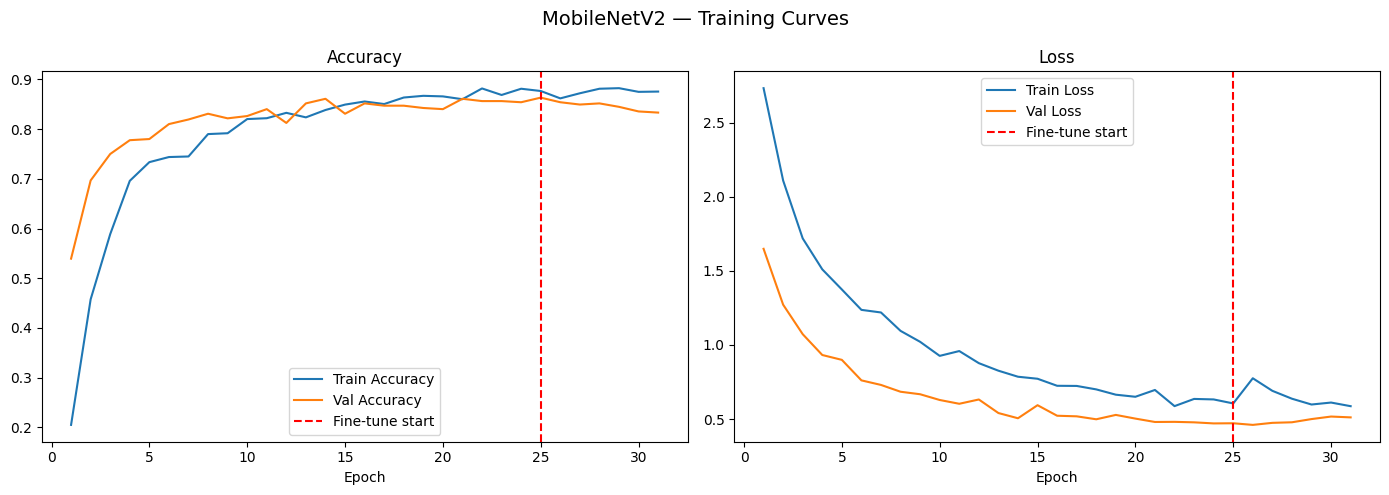

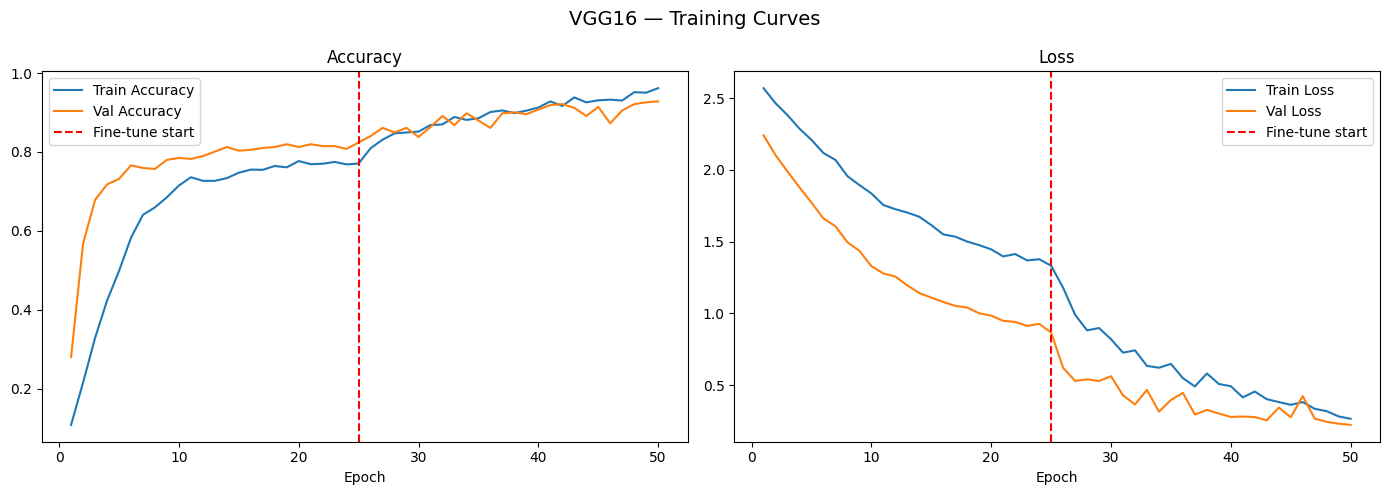

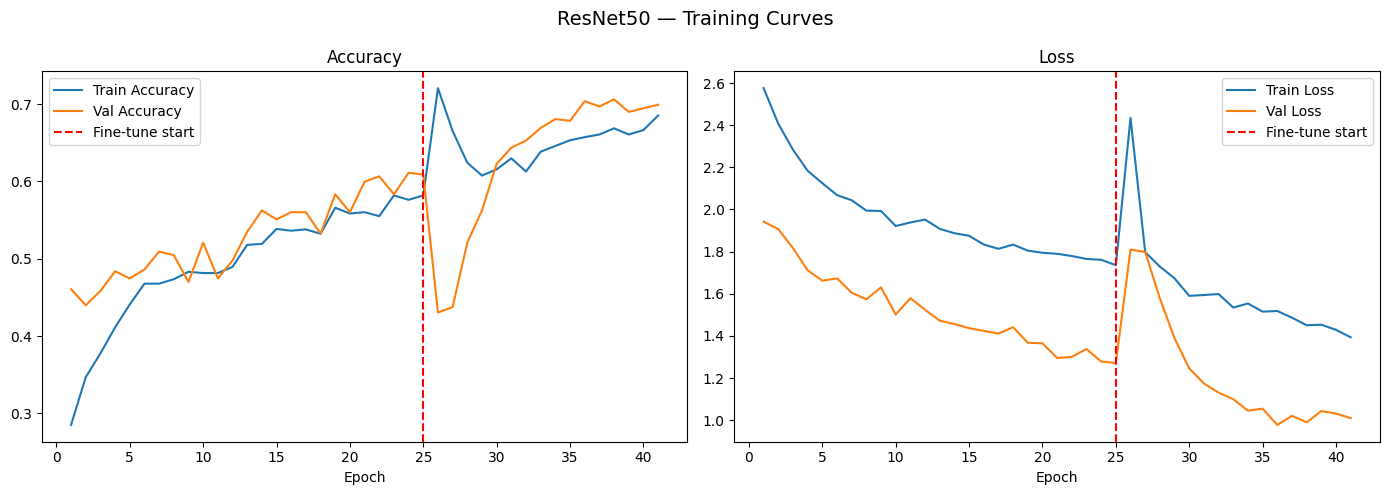

In [18]:
def plot_history(history_1, history_2, model_name):
    """
    Plot accuracy and loss curves across both training phases.

    Phase 1 and Phase 2 histories are concatenated into a single timeline.
    A vertical dashed red line marks the epoch where fine-tuning began.
    """
    acc      = history_1.history['accuracy']     + history_2.history['accuracy']
    val_acc  = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
    loss     = history_1.history['loss']         + history_2.history['loss']
    val_loss = history_1.history['val_loss']     + history_2.history['val_loss']
    epochs   = range(1, len(acc) + 1)              # Epoch numbers for the x-axis
    ft_start = len(history_1.history['accuracy'])  # Index where Phase 2 begins

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training Curves', fontsize=14)

    ax1.plot(epochs, acc,     label='Train Accuracy')
    ax1.plot(epochs, val_acc, label='Val Accuracy')
    ax1.axvline(ft_start, color='red', linestyle='--', label='Fine-tune start')  # Phase boundary
    ax1.set_title('Accuracy') ; ax1.set_xlabel('Epoch') ; ax1.legend()

    ax2.plot(epochs, loss,     label='Train Loss')
    ax2.plot(epochs, val_loss, label='Val Loss')
    ax2.axvline(ft_start, color='red', linestyle='--', label='Fine-tune start')
    ax2.set_title('Loss') ; ax2.set_xlabel('Epoch') ; ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{model_name}_training_curves.png', dpi=150)  # Save figure to disk
    plt.show()

plot_history(mobilenet_history_1, mobilenet_history_2, 'MobileNetV2')
plot_history(vgg_history_1,       vgg_history_2,       'VGG16')
plot_history(resnet_history_1,    resnet_history_2,    'ResNet50')


## Step 12 — Evaluation on Test Set

Per-class precision, recall, F1-score and confusion matrix for each model.


--------------------------------------------------
  Evaluating MobileNetV2
--------------------------------------------------
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step

Classification Report:
                    precision    recall  f1-score   support

          Vitiligo       1.00      0.97      0.98       267
        tinea-body       0.76      0.76      0.76        29
        tinea-face       0.74      0.88      0.80        16
 tinea-foot-dorsum       0.58      0.64      0.61        11
tinea-foot-plantar       0.62      0.56      0.59         9
   tinea-foot-webs       0.93      0.76      0.84        17
       tinea-groin       1.00      0.83      0.91        29
 tinea-hand-dorsum       0.62      0.73      0.67        11
        tinea-palm       0.50      0.67      0.57         6
       tinea-scalp       0.88      0.93      0.90        15
  tinea-versicolor       0.69      0.89      0.77        27

          accuracy                           0.90       437
         macro avg       0.

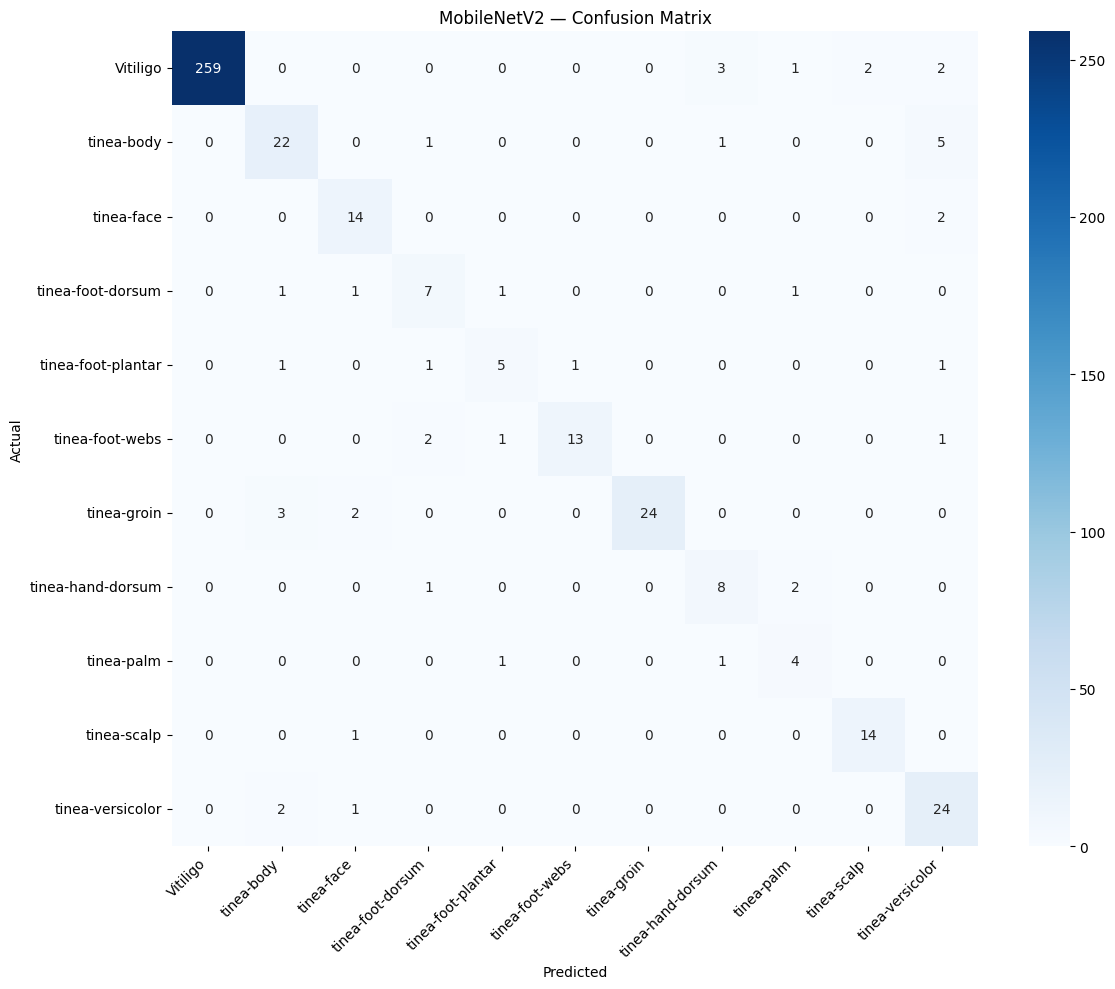

Overall Test Accuracy: 0.9016

--------------------------------------------------
  Evaluating VGG16
--------------------------------------------------
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 514ms/step

Classification Report:
                    precision    recall  f1-score   support

          Vitiligo       1.00      1.00      1.00       267
        tinea-body       0.79      0.66      0.72        29
        tinea-face       0.87      0.81      0.84        16
 tinea-foot-dorsum       0.50      0.36      0.42        11
tinea-foot-plantar       0.50      0.89      0.64         9
   tinea-foot-webs       0.94      0.88      0.91        17
       tinea-groin       0.97      0.97      0.97        29
 tinea-hand-dorsum       0.80      0.73      0.76        11
        tinea-palm       0.75      1.00      0.86         6
       tinea-scalp       0.88      0.93      0.90        15
  tinea-versicolor       0.79      0.85      0.82        27

          accuracy                           0.92       437


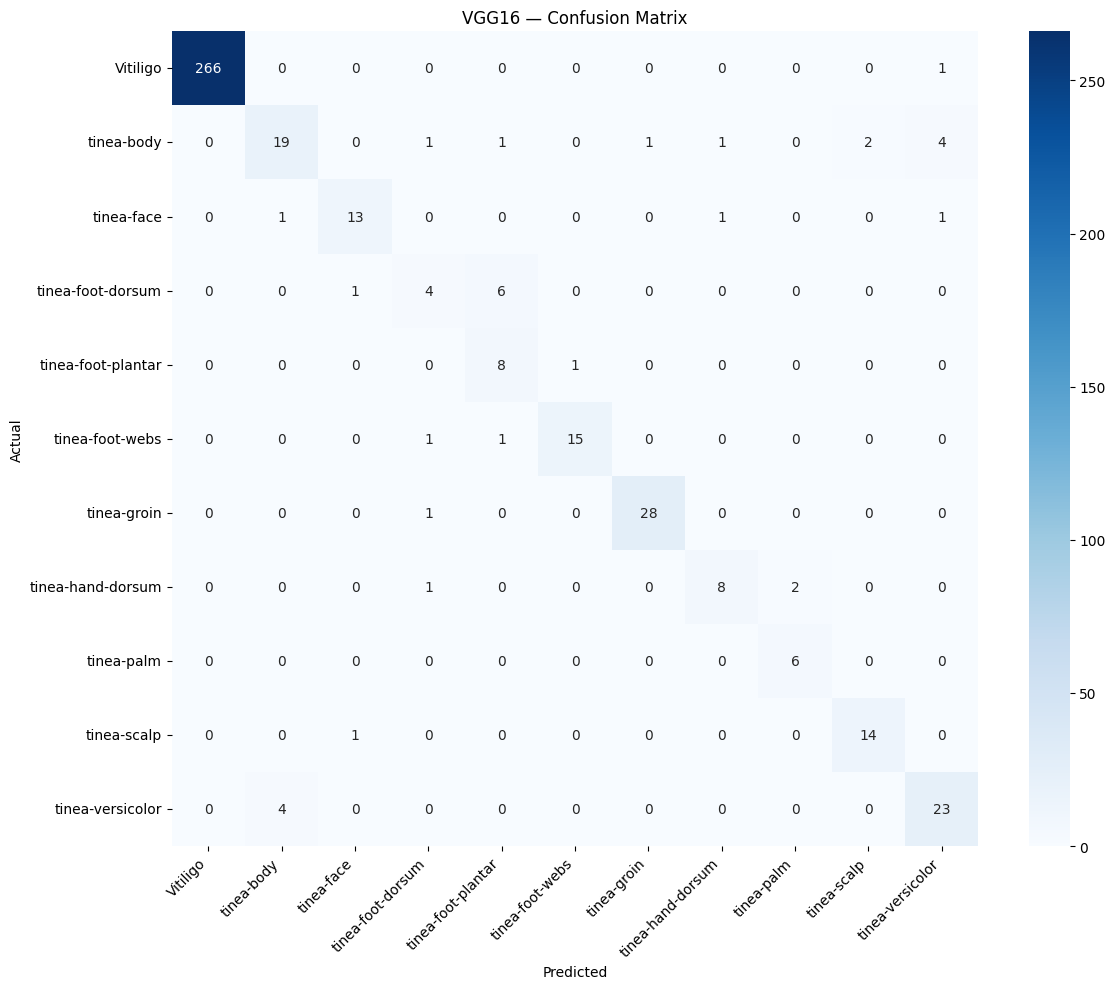

Overall Test Accuracy: 0.9245

--------------------------------------------------
  Evaluating ResNet50
--------------------------------------------------
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 388ms/step

Classification Report:
                    precision    recall  f1-score   support

          Vitiligo       0.97      0.85      0.90       267
        tinea-body       0.62      0.17      0.27        29
        tinea-face       0.00      0.00      0.00        16
 tinea-foot-dorsum       0.25      0.18      0.21        11
tinea-foot-plantar       0.27      0.33      0.30         9
   tinea-foot-webs       0.30      0.41      0.35        17
       tinea-groin       0.59      0.55      0.57        29
 tinea-hand-dorsum       0.25      0.27      0.26        11
        tinea-palm       0.33      0.67      0.44         6
       tinea-scalp       0.36      0.93      0.52        15
  tinea-versicolor       0.33      0.74      0.45        27

          accuracy                           0.69       4

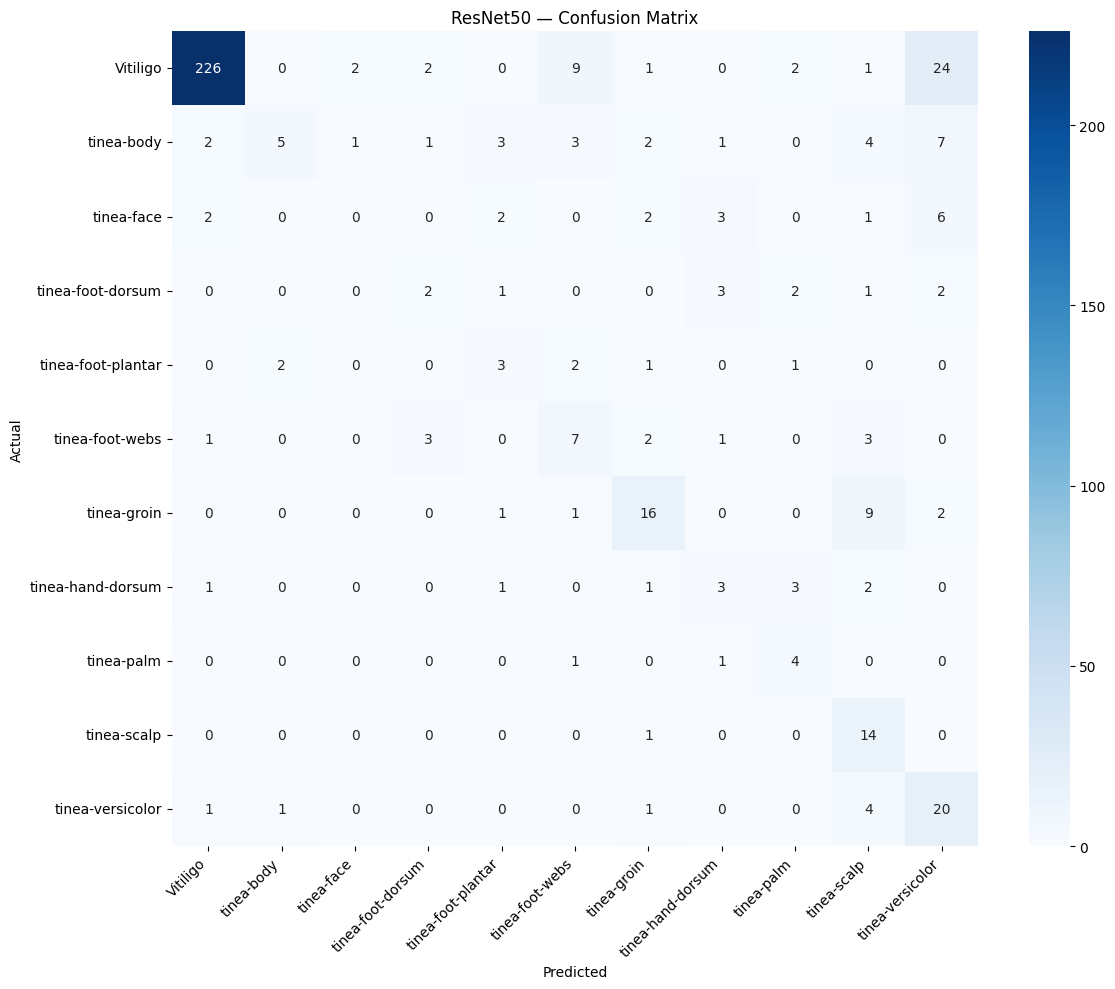

Overall Test Accuracy: 0.6865


In [16]:
def evaluate_model(model, test_ds, model_name):
    """
    Evaluate a trained model on the test set.

    Prints a per-class classification report and saves a confusion matrix PNG.
    Returns a dict with y_true, y_pred, and overall accuracy for further comparison.
    """
    print(f'\n{"-"*50}\n  Evaluating {model_name}\n{"-"*50}')

    y_pred_probs = model.predict(test_ds)                            # Softmax probability vectors
    y_pred       = np.argmax(y_pred_probs, axis=1)                   # Predicted class per image
    y_true       = np.concatenate([y for x, y in test_ds], axis=0).astype(int)  # Ground-truth labels

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    # Confusion matrix: rows = actual class, columns = predicted class
    # Diagonal entries are correct predictions; off-diagonal entries are errors
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('Actual') ; plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')   # Rotate labels to prevent overlap
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png', dpi=150)
    plt.show()

    acc = np.mean(y_pred == y_true)   # Overall accuracy: correct / total
    print(f'Overall Test Accuracy: {acc:.4f}')
    return {'model': model_name, 'y_true': y_true, 'y_pred': y_pred, 'accuracy': acc}

mobilenet_results = evaluate_model(mobilenet_model, test_ds, 'MobileNetV2')
vgg_results       = evaluate_model(vgg_model,       test_ds, 'VGG16')
resnet_results    = evaluate_model(resnet_model,    test_ds, 'ResNet50')


## Step 13 — Model Comparison

Weighted average metrics across all 11 classes for final comparison.


   MobileNetV2 vs VGG16 vs ResNet50 — Final Comparison
Metric          MobileNetV2      VGG16   ResNet50
--------------------------------------------------
Accuracy             0.9016     0.9245     0.6865
Precision            0.9131     0.9281     0.7406
Recall               0.9016     0.9245     0.6865
F1-Score              0.905      0.924     0.6918


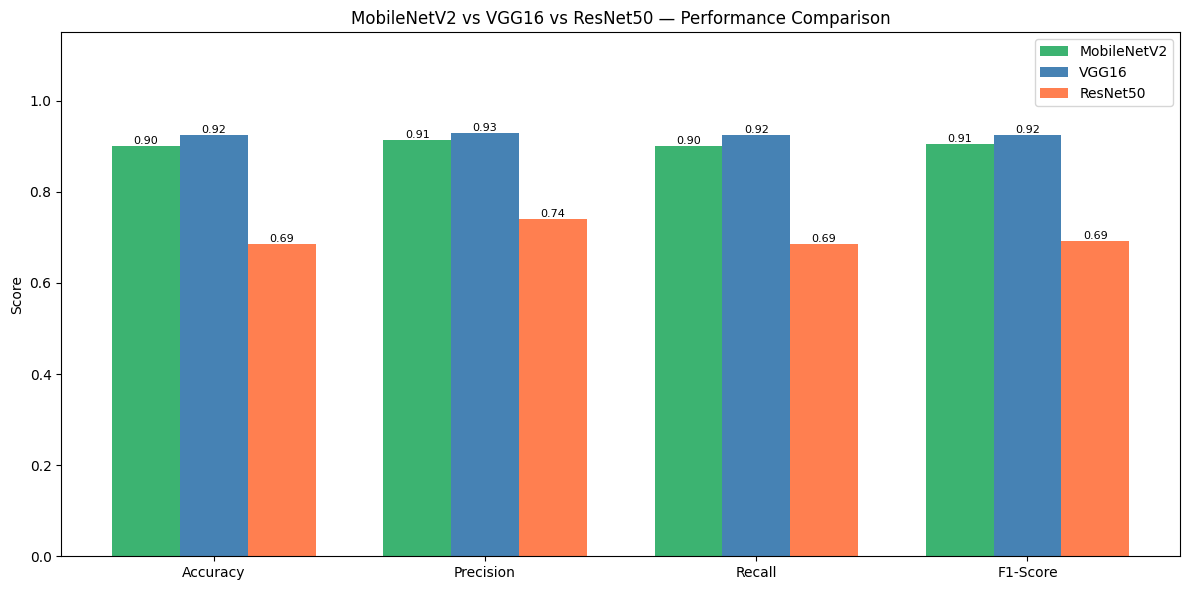

In [19]:
def get_metrics(results):
    """
    Extract weighted-average Accuracy, Precision, Recall, and F1 from a results dict.
    'weighted' weights each class score by its test-set sample count — fair under imbalance.
    """
    y_true, y_pred = results['y_true'], results['y_pred']
    return {
        'Model'    : results['model'],
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred,    average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred,        average='weighted', zero_division=0), 4),
    }

mobilenet_metrics = get_metrics(mobilenet_results)
vgg_metrics       = get_metrics(vgg_results)
resnet_metrics    = get_metrics(resnet_results)

print('\n' + '=' * 70)
print('   MobileNetV2 vs VGG16 vs ResNet50 — Final Comparison')
print('=' * 70)
print(f'{"Metric":<12} {"MobileNetV2":>14} {"VGG16":>10} {"ResNet50":>10}')
print('-' * 50)
for key in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    print(f'{key:<12} {mobilenet_metrics[key]:>14} {vgg_metrics[key]:>10} {resnet_metrics[key]:>10}')
print('=' * 70)

# ── Bar chart: visualise the comparison across all four metrics ──────────
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
mobilenet_vals = [mobilenet_metrics[m] for m in metrics_names]
vgg_vals       = [vgg_metrics[m]       for m in metrics_names]
resnet_vals    = [resnet_metrics[m]    for m in metrics_names]

x     = np.arange(len(metrics_names))   # One group of bars per metric
width = 0.25                             # Width of each bar (3 bars fit side-by-side)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, mobilenet_vals, width, label='MobileNetV2', color='mediumseagreen')
ax.bar(x,         vgg_vals,       width, label='VGG16',       color='steelblue')
ax.bar(x + width, resnet_vals,    width, label='ResNet50',    color='coral')
ax.set_xticks(x) ; ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.15)          # Headroom above 1.0 for value labels
ax.set_title('MobileNetV2 vs VGG16 vs ResNet50 — Performance Comparison')
ax.legend() ; ax.set_ylabel('Score')
for bar in ax.patches:   # Annotate each bar with its rounded value
    ax.annotate(f'{bar.get_height():.2f}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('MobileNetV2_vs_VGG16_vs_ResNet50_comparison.png', dpi=150)
plt.show()


## Step 14 — Save Models

In [17]:
# Save final models in Keras native format.
# These reflect the post-fine-tuning weights and are ready for inference or deployment.
# (ModelCheckpoint already saved the best validation-loss checkpoints during training.)
mobilenet_model.save('mobilenet_final.keras')
vgg_model.save('vgg16_final.keras')
resnet_model.save('resnet50_final.keras')

print('Models saved:')
print('  mobilenet_final.keras')
print('  vgg16_final.keras')
print('  resnet50_final.keras')


Models saved:
  mobilenet_final.keras
  vgg16_final.keras
  resnet50_final.keras


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---

## Summary

| File | Description |
|---|---|
| `best_mobilenet_phase2.keras` | Best MobileNetV2 checkpoint |
| `best_vgg16_phase2.keras` | Best VGG16 checkpoint |
| `best_resnet50_phase2.keras` | Best ResNet50 checkpoint |
| `mobilenet_final.keras` | Final MobileNetV2 model |
| `vgg16_final.keras` | Final VGG16 model |
| `resnet50_final.keras` | Final ResNet50 model |
| `MobileNetV2_training_curves.png` | MobileNetV2 training curves |
| `VGG16_training_curves.png` | VGG16 training curves |
| `ResNet50_training_curves.png` | ResNet50 training curves |
| `MobileNetV2_confusion_matrix.png` | MobileNetV2 confusion matrix |
| `VGG16_confusion_matrix.png` | VGG16 confusion matrix |
| `ResNet50_confusion_matrix.png` | ResNet50 confusion matrix |
| `MobileNetV2_vs_VGG16_vs_ResNet50_comparison.png` | Final comparison chart |